## Block 0 — Setup and configuration

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data' / 'obd2'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'

(MODELS_DIR / 'pkl').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'onnx').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

if DATA_DIR.exists():
    for p in sorted(DATA_DIR.iterdir()):
        if p.is_file():
            print(f"  {p.name}  ({p.stat().st_size / 1024 / 1024:.1f} MB)")

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

FEATURE_COLS = [
    'ENGINE_RPM',
    'THROTTLE_POS',
    'ENGINE_COOLANT_TEMP',
    'ENGINE_LOAD',
    'SPEED',
    'INTAKE_MANIFOLD_PRESSURE',
]

CLASS_NAMES = ['Normal', 'Diagnostic', 'Critical']
CLASS_COLORS = ['#10b981', '#f59e0b', '#dc2626']

print(f"\nModel input features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  - {f}")
print(f"\nOutput classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} = {name}")

Project root: d:\v2
Data dir:     d:\v2\data\obd2
  exp1_14drivers_14cars_dailyRoutes.csv  (6.7 MB)

Model input features (6):
  - ENGINE_RPM
  - THROTTLE_POS
  - ENGINE_COOLANT_TEMP
  - ENGINE_LOAD
  - SPEED
  - INTAKE_MANIFOLD_PRESSURE

Output classes:
  0 = Normal
  1 = Diagnostic
  2 = Critical


## Block 1 — Load OBD-II raw data

In [2]:
csv_path = DATA_DIR / 'exp1_14drivers_14cars_dailyRoutes.csv'

t0 = time.time()
df = pd.read_csv(csv_path, low_memory=False)
print(f"Loaded in {time.time()-t0:.1f} sec")

print(f"\nShape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  - {c}")

print(f"\nMemory: {df.memory_usage(deep=False).sum() / 1024**2:.1f} MB")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

Loaded in 0.2 sec

Shape: (60439, 33)
Columns (33):
  - TIMESTAMP
  - MARK
  - MODEL
  - CAR_YEAR
  - ENGINE_POWER
  - AUTOMATIC
  - VEHICLE_ID
  - BAROMETRIC_PRESSURE(KPA)
  - ENGINE_COOLANT_TEMP
  - FUEL_LEVEL
  - ENGINE_LOAD
  - AMBIENT_AIR_TEMP
  - ENGINE_RPM
  - INTAKE_MANIFOLD_PRESSURE
  - MAF
  - LONG TERM FUEL TRIM BANK 2
  - FUEL_TYPE
  - AIR_INTAKE_TEMP
  - FUEL_PRESSURE
  - SPEED
  - SHORT TERM FUEL TRIM BANK 2
  - SHORT TERM FUEL TRIM BANK 1
  - ENGINE_RUNTIME
  - THROTTLE_POS
  - DTC_NUMBER
  - TROUBLE_CODES
  - TIMING_ADVANCE
  - EQUIV_RATIO
  - MIN
  - HOURS
  - DAYS_OF_WEEK
  - MONTHS
  - YEAR

Memory: 15.2 MB

First 3 rows:
      TIMESTAMP       MARK  MODEL  CAR_YEAR ENGINE_POWER AUTOMATIC VEHICLE_ID  BAROMETRIC_PRESSURE(KPA)  ENGINE_COOLANT_TEMP FUEL_LEVEL ENGINE_LOAD  AMBIENT_AIR_TEMP  ENGINE_RPM  INTAKE_MANIFOLD_PRESSURE   MAF LONG TERM FUEL TRIM BANK 2          FUEL_TYPE  AIR_INTAKE_TEMP  FUEL_PRESSURE  SPEED SHORT TERM FUEL TRIM BANK 2 SHORT TERM FUEL TRIM BANK 1 

## Block 2 — Parse European decimal format and filter NaN

In [3]:
def parse_european_float(x):
    """Convert '4,49' (European) → 4.49 (float)."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().rstrip('%').replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return np.nan

print(f"Parsing {len(FEATURE_COLS)} sensor columns to numeric:")
for c in FEATURE_COLS:
    if c in df.columns:
        df[c] = df[c].apply(parse_european_float)
        nan_count = df[c].isna().sum()
        print(f"  {c:30}  NaN: {nan_count:>6,}  ({nan_count/len(df)*100:.1f}%)")
    else:
        print(f"  {c:30}  ✗ MISSING IN DATA")

before = len(df)
df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"\nFiltered rows with NaN in any feature: {before:,} → {len(df):,}")

print(f"\nFeature value ranges (after filtering):")
print(df[FEATURE_COLS].describe().round(2).to_string())

Parsing 6 sensor columns to numeric:
  ENGINE_RPM                      NaN: 26,580  (44.0%)
  THROTTLE_POS                    NaN: 26,580  (44.0%)
  ENGINE_COOLANT_TEMP             NaN: 26,475  (43.8%)
  ENGINE_LOAD                     NaN: 29,467  (48.8%)
  SPEED                           NaN: 13,910  (23.0%)
  INTAKE_MANIFOLD_PRESSURE        NaN: 35,350  (58.5%)

Filtered rows with NaN in any feature: 60,439 → 20,071

Feature value ranges (after filtering):
       ENGINE_RPM  THROTTLE_POS  ENGINE_COOLANT_TEMP  ENGINE_LOAD     SPEED  INTAKE_MANIFOLD_PRESSURE
count    20071.00      20071.00             20071.00     20071.00  20071.00                  20071.00
mean      1482.70         16.60                78.59        34.71     29.72                     46.20
std        550.03          9.46                11.29        17.99     23.12                     19.24
min        438.00          1.00                22.00         5.10      0.00                     13.00
25%        950.00         

## Block 3 — Generate synthetic stress labels (engineering rules)

In [4]:
def classify_stress(row):
    """Return 0 (Normal), 1 (Diagnostic), 2 (Critical) for one OBD reading."""
    rpm = row['ENGINE_RPM']
    throttle = row['THROTTLE_POS']
    coolant = row['ENGINE_COOLANT_TEMP']
    load = row['ENGINE_LOAD']
    speed = row['SPEED']
    manifold = row['INTAKE_MANIFOLD_PRESSURE']
    
    critical = (
        coolant >= 95 or                        
        rpm >= 2500 or                          
        throttle >= 40 or                       
        (rpm >= 2000 and load >= 70) or         
        (load >= 80 and coolant >= 88) or       
        (throttle >= 30 and speed < 5)          
    )
    if critical:
        return 2
    
    diagnostic = (
        coolant >= 88 or                        
        rpm >= 1800 or                          
        load >= 50 or                           
        throttle >= 25 or                       
        (manifold >= 70 and rpm < 1000)         
    )
    if diagnostic:
        return 1
    
    return 0

t0 = time.time()
df['stress_class'] = df.apply(classify_stress, axis=1)
print(f"Stress classification took {time.time()-t0:.1f} sec")

class_counts = df['stress_class'].value_counts().sort_index()
print(f"\nStress class distribution:")
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {cls} ({CLASS_NAMES[cls]:<11}): {count:>7,}  ({pct:>5.2f}%)")

print(f"\nTotal samples: {len(df):,}")

if class_counts.get(2, 0) == 0:
    print("\n⚠ WARNING: 0 Critical samples. Rules need further softening.")
elif class_counts.get(2, 0) < 100:
    print(f"\n⚠ WARNING: only {class_counts.get(2, 0)} Critical samples — very small class.")


Stress classification took 0.2 sec

Stress class distribution:
  0 (Normal     ):   9,136  (45.52%)
  1 (Diagnostic ):   8,878  (44.23%)
  2 (Critical   ):   2,057  (10.25%)

Total samples: 20,071


## Block 4 — EDA: feature distributions per class

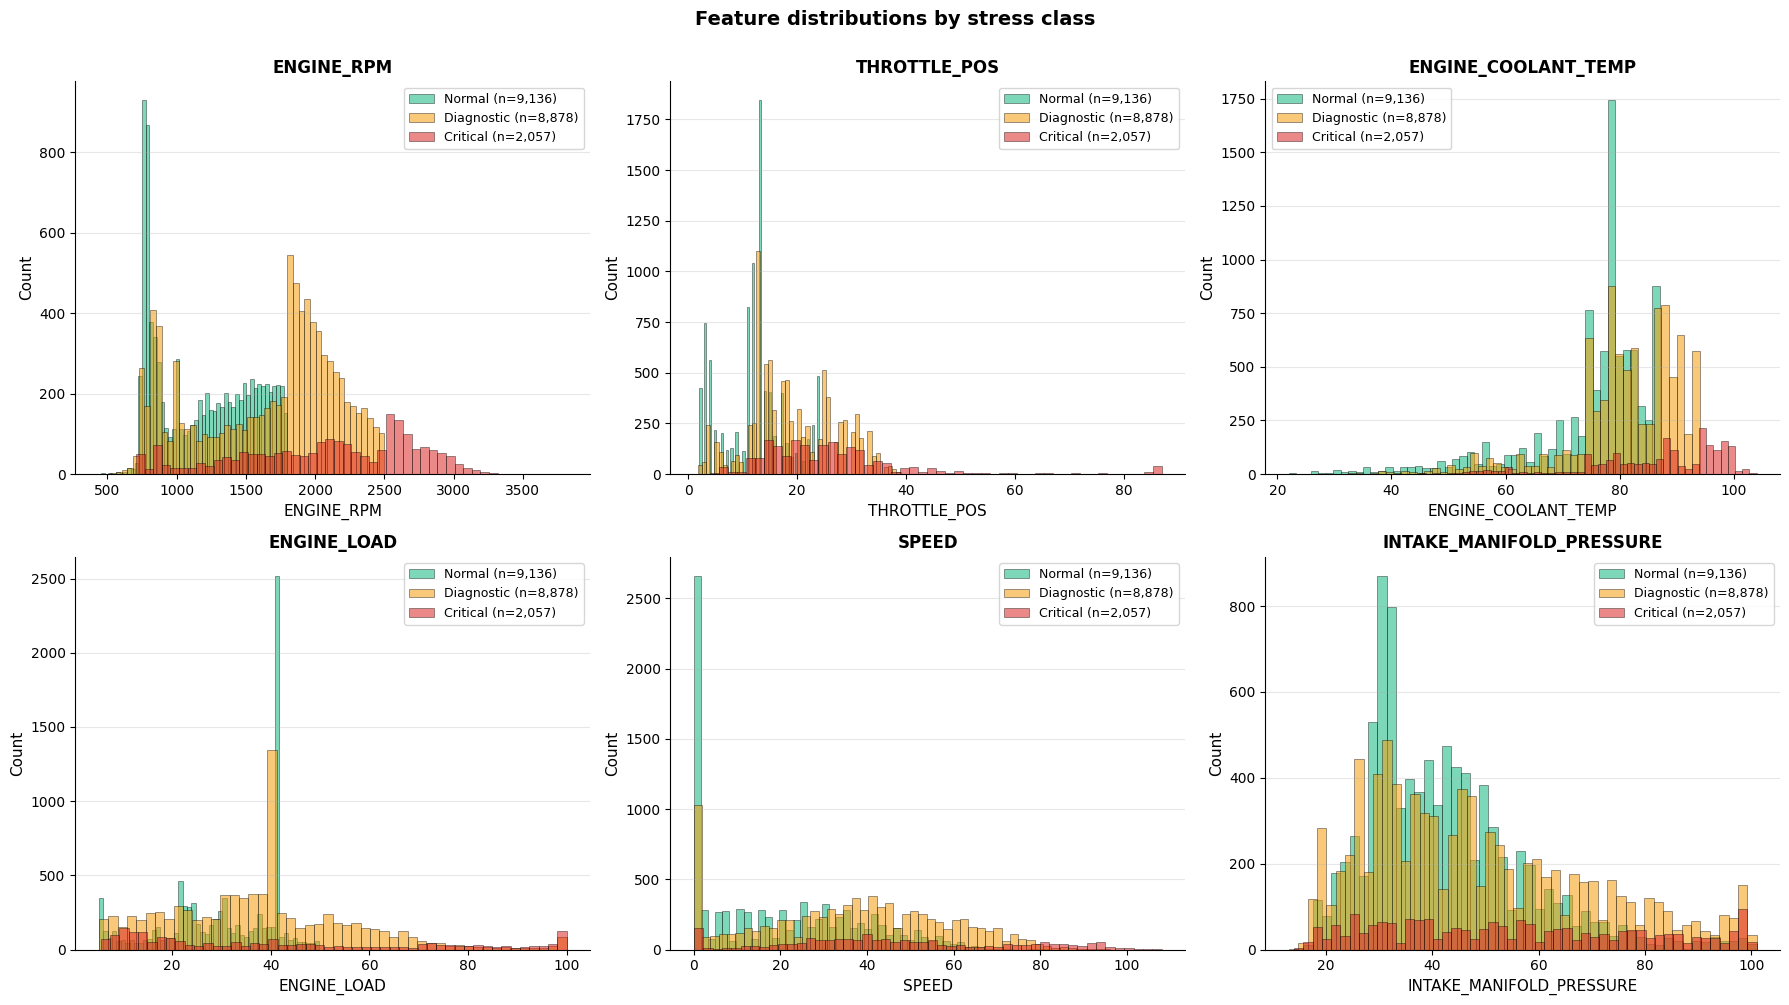

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), FEATURE_COLS):
    for cls in range(3):
        data = df[df['stress_class'] == cls][feature]
        ax.hist(data, bins=50, alpha=0.55, color=CLASS_COLORS[cls],
                label=f'{CLASS_NAMES[cls]} (n={len(data):,})',
                edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Count')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature distributions by stress class', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'obd_01_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 5 — Train XGBoost multiclass classifier

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['stress_class'].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"\nTrain class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'hist',
    'max_depth': 5,
    'learning_rate': 0.1,
    'n_estimators': 300,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'eval_metric': 'mlogloss',
}

t0 = time.time()
model = xgb.XGBClassifier(**xgb_params)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
train_time = time.time() - t0
print(f"\nTrained in {train_time:.1f} sec")

y_proba = model.predict_proba(X_test)
y_pred = y_proba.argmax(axis=1).astype(np.int32)

print(f"\nDebug shapes:")
print(f"  y_test shape:  {y_test.shape}  (dtype: {y_test.dtype})")
print(f"  y_pred shape:  {y_pred.shape}  (dtype: {y_pred.dtype})")
print(f"  y_proba shape: {y_proba.shape}  (dtype: {y_proba.dtype})")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {accuracy:.4f}")

present_classes = sorted(set(y_test) | set(y_pred))
present_names = [CLASS_NAMES[c] for c in present_classes]
print(f"\nClasses present in test set: {present_classes} → {present_names}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, labels=present_classes,
                            target_names=present_names, digits=4))

Train: 16,056 samples
Test:  4,015 samples

Train class distribution: {np.int32(0): np.int64(7308), np.int32(1): np.int64(7102), np.int32(2): np.int64(1646)}
Test class distribution:  {np.int32(0): np.int64(1828), np.int32(1): np.int64(1776), np.int32(2): np.int64(411)}
[0]	validation_0-mlogloss:0.85844
[50]	validation_0-mlogloss:0.03872
[100]	validation_0-mlogloss:0.01007
[150]	validation_0-mlogloss:0.00793
[200]	validation_0-mlogloss:0.00777
[250]	validation_0-mlogloss:0.00775
[299]	validation_0-mlogloss:0.00786

Trained in 0.8 sec

Debug shapes:
  y_test shape:  (4015,)  (dtype: int32)
  y_pred shape:  (4015,)  (dtype: int32)
  y_proba shape: (4015, 3)  (dtype: float32)

Test accuracy: 0.9973

Classes present in test set: [np.int32(0), np.int32(1), np.int32(2)] → ['Normal', 'Diagnostic', 'Critical']

Classification report:
              precision    recall  f1-score   support

      Normal     1.0000    0.9995    0.9997      1828
  Diagnostic     0.9977    0.9961    0.9969      1776

## Block 6 — Evaluation: confusion matrix and per-class metrics

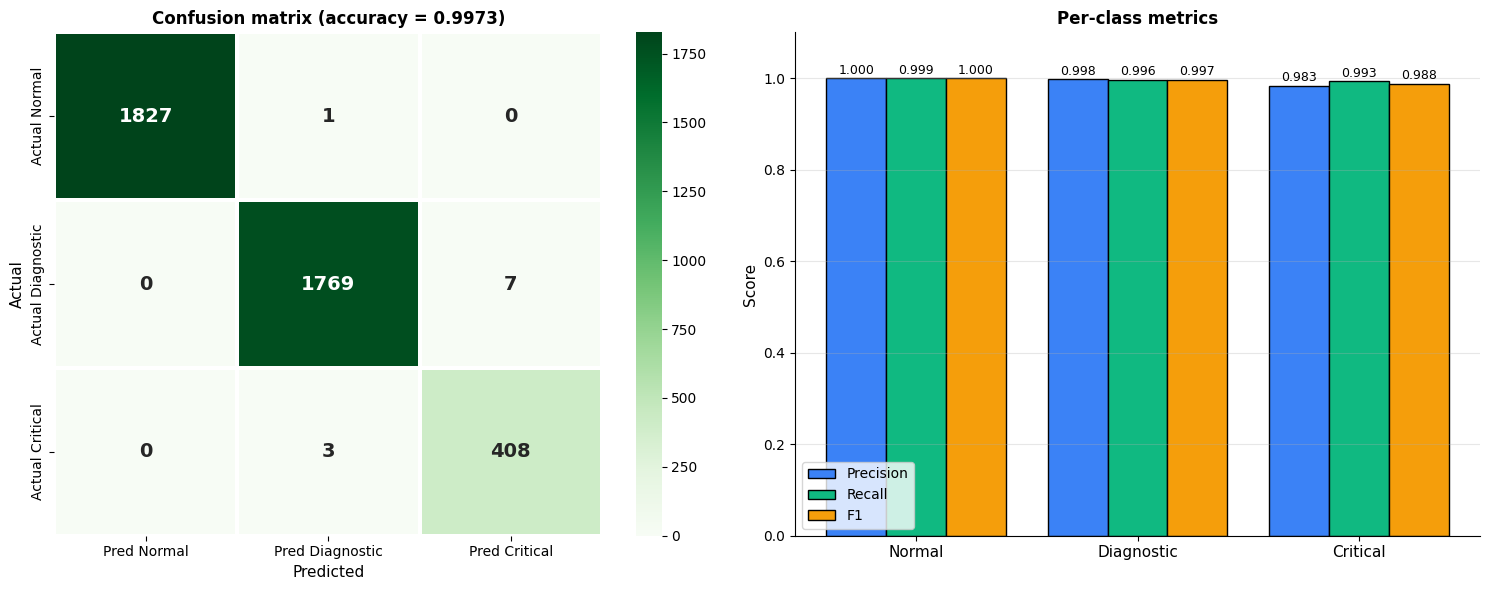

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[f'Pred {n}' for n in CLASS_NAMES],
            yticklabels=[f'Actual {n}' for n in CLASS_NAMES],
            ax=ax,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            linewidths=1.5, linecolor='white')
ax.set_title(f'Confusion matrix (accuracy = {accuracy:.4f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)

from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])

ax = axes[1]
x = np.arange(3)
width = 0.27
bars1 = ax.bar(x - width, prec, width, label='Precision', color='#3b82f6', edgecolor='black')
bars2 = ax.bar(x,         rec,  width, label='Recall',    color='#10b981', edgecolor='black')
bars3 = ax.bar(x + width, f1,   width, label='F1',        color='#f59e0b', edgecolor='black')

for bars in [bars1, bars2, bars3]:
    for bar, val in zip(bars, bars.datavalues if hasattr(bars, 'datavalues') else [b.get_height() for b in bars]):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-class metrics', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'obd_02_confusion.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 7 — SHAP feature importance (overall + per-class)

In [8]:
import shap
import plotly.graph_objects as go

np.random.seed(SEED)
shap_idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap = X_test[shap_idx]

t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP computed in {time.time()-t0:.1f} sec")
print(f"SHAP values shape: {shap_values.shape if hasattr(shap_values, 'shape') else [s.shape for s in shap_values]}")

if isinstance(shap_values, list):
    shap_per_class = shap_values
elif shap_values.ndim == 3:
    shap_per_class = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
else:
    shap_per_class = [shap_values]

mean_abs_shap_all = np.mean([np.abs(s).mean(axis=0) for s in shap_per_class], axis=0)
top_idx = np.argsort(mean_abs_shap_all)[::-1]

print(f"\nFeature importance ranking:")
print(f"{'Rank':<6} {'Feature':<28} {'Mean |SHAP|':>12}")
print("-" * 50)
top_features = []
for rank, i in enumerate(top_idx, 1):
    feat = FEATURE_COLS[i]
    score = float(mean_abs_shap_all[i])
    print(f"  {rank:<4} {feat:<26} {score:>12.4f}")
    top_features.append({'feature': feat, 'mean_abs_shap': score})

top_features_per_class = {}
for cls in range(min(3, len(shap_per_class))):
    mean_abs_cls = np.abs(shap_per_class[cls]).mean(axis=0)
    top_idx_cls = np.argsort(mean_abs_cls)[::-1]
    top_features_per_class[CLASS_NAMES[cls]] = [
        {'feature': FEATURE_COLS[i], 'mean_abs_shap': float(mean_abs_cls[i])}
        for i in top_idx_cls
    ]

# ═══ Plotly figure for dashboard ═══════════════════════════
# Single horizontal bar of mean |SHAP|, sorted descending.
# Color gradient from light blue (low) to deep blue (high importance).

DISPLAY_NAMES = {
    'ENGINE_RPM':                'Engine RPM',
    'THROTTLE_POS':              'Throttle position',
    'ENGINE_COOLANT_TEMP':       'Coolant temperature',
    'ENGINE_LOAD':               'Engine load',
    'SPEED':                     'Vehicle speed',
    'INTAKE_MANIFOLD_PRESSURE':  'Manifold pressure',
}

# Reverse the ranking so the largest bar sits at the TOP of the chart
order = top_idx[::-1]
labels = [DISPLAY_NAMES.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in order]
values = [float(mean_abs_shap_all[i]) for i in order]
ranks  = [int(np.where(top_idx == i)[0][0]) + 1 for i in order]

# Per-class breakdown for hover detail
hover_extra = []
for i in order:
    parts = []
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        v = float(np.abs(shap_per_class[cls_idx][:, i]).mean()) if cls_idx < len(shap_per_class) else 0
        parts.append(f"{cls_name}: {v:.3f}")
    hover_extra.append('<br>'.join(parts))

# Light-to-deep blue gradient (RGB interpolation)
max_v = max(values) if values else 1.0
def _color(v):
    t = v / max_v if max_v > 0 else 0
    r = int(219 + (30  - 219) * t)
    g = int(234 + (64  - 234) * t)
    b = int(254 + (175 - 254) * t)
    return f'rgb({r},{g},{b})'

colors = [_color(v) for v in values]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=values,
    y=labels,
    orientation='h',
    marker=dict(color=colors, line=dict(color='rgba(15,23,42,0.18)', width=1)),
    text=[f'{v:.3f}' for v in values],
    textposition='outside',
    textfont=dict(family='JetBrains Mono, monospace', size=11, color='#475569'),
    customdata=list(zip(ranks, hover_extra)),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Mean |SHAP| = <b>%{x:.4f}</b><br>'
        'Rank: %{customdata[0]} of 6<br><br>'
        '<i>Per-class contribution:</i><br>%{customdata[1]}'
        '<extra></extra>'
    ),
))

fig.update_layout(
    title=dict(
        text='Feature importance by mean |SHAP| value',
        font=dict(family='Plus Jakarta Sans, sans-serif', size=15, color='#0F172A'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(
        title=dict(text='Mean |SHAP| value', font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0',
        showline=False,
        zeroline=False,
    ),
    yaxis=dict(
        tickfont=dict(family='Plus Jakarta Sans', size=12, color='#1E293B'),
        showgrid=False,
        autorange='reversed',
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=170, r=80, t=60, b=50),
    height=340,
    showlegend=False,
    font=dict(family='Plus Jakarta Sans, sans-serif'),
    hoverlabel=dict(
        bgcolor='#0F172A',
        bordercolor='#0F172A',
        font=dict(family='Plus Jakarta Sans', size=12, color='white'),
    ),
)

# Export Plotly JSON for dashboard
plot_json_path = OUTPUTS_DIR / 'data' / 'obd_03_shap_plot.json'
plot_json_path.write_text(fig.to_json(), encoding='utf-8')
print(f"\nPlotly JSON: {plot_json_path.name}  ({plot_json_path.stat().st_size / 1024:.1f} KB)")

# Export PNG for thesis PDF (requires kaleido)
png_path = OUTPUTS_DIR / 'plots' / 'obd_03_shap.png'
try:
    fig.write_image(png_path, width=900, height=380, scale=2)
    print(f"PNG:         {png_path.name}  ({png_path.stat().st_size / 1024:.1f} KB)")
except Exception as e:
    print(f"PNG export skipped — install kaleido: pip install -U kaleido  ({type(e).__name__})")

fig.show()


SHAP computed in 1.5 sec
SHAP values shape: (2000, 6, 3)

Feature importance ranking:
Rank   Feature                       Mean |SHAP|
--------------------------------------------------
  1    ENGINE_RPM                       1.8852
  2    ENGINE_COOLANT_TEMP              1.2827
  3    THROTTLE_POS                     1.1217
  4    ENGINE_LOAD                      0.8811
  5    INTAKE_MANIFOLD_PRESSURE         0.2955
  6    SPEED                            0.2687

Plotly JSON: obd_03_shap_plot.json  (8.7 KB)
PNG:         obd_03_shap.png  (80.4 KB)


## Block 8 — Test scenarios for dashboard demo

In [9]:
print("Finding representative scenarios from test set...")

scenarios = []
for target_class, name in enumerate(CLASS_NAMES):
    mask = y_test == target_class
    indices = np.where(mask)[0]
    probas_for_class = y_proba[indices, target_class]
    most_confident_idx_in_class = indices[probas_for_class.argmax()]
    
    sample_features = X_test[most_confident_idx_in_class]
    sample_proba = y_proba[most_confident_idx_in_class]
    
    print(f"\n{name} scenario:")
    for fname, fval in zip(FEATURE_COLS, sample_features):
        print(f"  {fname:30} = {fval:>7.1f}")
    print(f"  Predicted class: {CLASS_NAMES[sample_proba.argmax()]}")
    print(f"  Probabilities: {dict(zip(CLASS_NAMES, [round(p, 4) for p in sample_proba]))}")
    
    scenarios.append({
        'scenario': name.lower(),
        'class_name': name,
        'features': {fname: float(fval) for fname, fval in zip(FEATURE_COLS, sample_features)},
        'features_array': sample_features.tolist(),
        'expected_class': int(target_class),
        'expected_proba': sample_proba.tolist(),
    })

print(f"\n✓ {len(scenarios)} scenarios saved")

Finding representative scenarios from test set...

Normal scenario:
  ENGINE_RPM                     =  1370.0
  THROTTLE_POS                   =    13.0
  ENGINE_COOLANT_TEMP            =    78.0
  ENGINE_LOAD                    =    37.3
  SPEED                          =     5.0
  INTAKE_MANIFOLD_PRESSURE       =    43.0
  Predicted class: Normal
  Probabilities: {'Normal': np.float32(1.0), 'Diagnostic': np.float32(0.0), 'Critical': np.float32(0.0)}

Diagnostic scenario:
  ENGINE_RPM                     =  1818.0
  THROTTLE_POS                   =    19.0
  ENGINE_COOLANT_TEMP            =    70.0
  ENGINE_LOAD                    =    51.4
  SPEED                          =    28.0
  INTAKE_MANIFOLD_PRESSURE       =    65.0
  Predicted class: Diagnostic
  Probabilities: {'Normal': np.float32(0.0), 'Diagnostic': np.float32(1.0), 'Critical': np.float32(0.0)}

Critical scenario:
  ENGINE_RPM                     =  2689.0
  THROTTLE_POS                   =    50.0
  ENGINE_COOLANT_TEMP 

## Block 9 — Slider ranges for dashboard UI

In [10]:
SLIDER_RANGES = {
    'ENGINE_RPM':                {'min': 600,  'max': 7000, 'step': 50,  'default': 1500, 'unit': 'rpm'},
    'THROTTLE_POS':              {'min': 0,    'max': 100,  'step': 1,   'default': 15,   'unit': '%'},
    'ENGINE_COOLANT_TEMP':       {'min': 40,   'max': 130,  'step': 1,   'default': 90,   'unit': '°C'},
    'ENGINE_LOAD':               {'min': 0,    'max': 100,  'step': 1,   'default': 30,   'unit': '%'},
    'SPEED':                     {'min': 0,    'max': 200,  'step': 1,   'default': 60,   'unit': 'km/h'},
    'INTAKE_MANIFOLD_PRESSURE':  {'min': 20,   'max': 250,  'step': 1,   'default': 60,   'unit': 'kPa'},
}

print("Slider ranges for dashboard UI:")
for feat, r in SLIDER_RANGES.items():
    print(f"  {feat:30} {r['min']:>4} – {r['max']:>4} {r['unit']:<5}  default={r['default']}")

Slider ranges for dashboard UI:
  ENGINE_RPM                      600 – 7000 rpm    default=1500
  THROTTLE_POS                      0 –  100 %      default=15
  ENGINE_COOLANT_TEMP              40 –  130 °C     default=90
  ENGINE_LOAD                       0 –  100 %      default=30
  SPEED                             0 –  200 km/h   default=60
  INTAKE_MANIFOLD_PRESSURE         20 –  250 kPa    default=60


## Block 10 — ONNX export and verification

In [11]:
import joblib
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
import onnxruntime as ort

pkl_path = MODELS_DIR / 'pkl' / 'obd_stress_xgb.pkl'
joblib.dump(model, pkl_path)
print(f"pkl: {pkl_path.name}  ({pkl_path.stat().st_size / 1024:.1f} KB)")

update_registered_converter(
    xgb.XGBClassifier, 'XGBoostXGBClassifier',
    calculate_linear_classifier_output_shapes, convert_xgboost,
    options={'nocl': [True, False], 'zipmap': [True, False, 'columns']},
)

initial_type = [('float_input', FloatTensorType([None, len(FEATURE_COLS)]))]

t0 = time.time()
onnx_model = convert_sklearn(
    model,
    initial_types=initial_type,
    options={id(model): {'zipmap': False}},
    target_opset={'': 15, 'ai.onnx.ml': 3},
)
onnx_path = MODELS_DIR / 'onnx' / 'obd_stress_xgb.onnx'
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"ONNX: {onnx_path.name}  ({onnx_path.stat().st_size / 1024:.1f} KB)")

session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name

onnx_outputs = session.run(None, {input_name: X_test.astype(np.float32)})
onnx_proba = None
for out in onnx_outputs:
    if out.ndim == 2 and out.shape[1] == 3:
        onnx_proba = out
        break

if onnx_proba is not None:
    max_diff = float(np.abs(y_proba - onnx_proba).max())
    mean_diff = float(np.abs(y_proba - onnx_proba).mean())
    onnx_pred = onnx_proba.argmax(axis=1)
    onnx_acc = (onnx_pred == y_test).mean()
    
    print(f"\nONNX verification:")
    print(f"  Max proba diff:   {max_diff:.2e}")
    print(f"  Mean proba diff:  {mean_diff:.2e}")
    print(f"  ONNX accuracy:    {onnx_acc:.4f}")
    print(f"  Match sklearn:    {'✓' if abs(onnx_acc - accuracy) < 1e-4 else '✗'}")

pkl: obd_stress_xgb.pkl  (1118.1 KB)
ONNX: obd_stress_xgb.onnx  (508.9 KB)

ONNX verification:
  Max proba diff:   4.17e-07
  Mean proba diff:  1.07e-08
  ONNX accuracy:    0.9973
  Match sklearn:    ✓


## Block 11 — Save artifacts (pkl + ONNX + JSON)

In [12]:
artifacts = {
    'subsystem': 'obd_stress_detector',
    'task': 'mechanical stress classification from real-time OBD-II readings',
    'dataset': {
        'name': 'OBD-II 14-drivers/14-cars (Kaggle, used as sensor source)',
        'total_readings_raw': 60439,
        'total_readings_filtered': int(len(df)),
        'features': len(FEATURE_COLS),
        'feature_cols': FEATURE_COLS,
    },
    'labeling_method': {
        'type': 'rule-based synthetic labels',
        'source': 'engineering best practices (Bosch Automotive Handbook, SAE J1979)',
        'note': 'Future work: validate against real fault data from instrumented vehicles',
    },
    'classes': {
        '0': {'name': 'Normal',     'color': CLASS_COLORS[0]},
        '1': {'name': 'Diagnostic', 'color': CLASS_COLORS[1]},
        '2': {'name': 'Critical',   'color': CLASS_COLORS[2]},
    },
    'class_distribution': {str(int(k)): int(v) for k, v in class_counts.items()},
    'model': {
        'type': 'XGBClassifier (multiclass softmax)',
        'params': {k: (int(v) if isinstance(v, np.integer) else v) for k, v in xgb_params.items()},
        'training_time_sec': float(train_time),
        'test_accuracy': float(accuracy),
    },
    'per_class_metrics': {
        CLASS_NAMES[i]: {
            'precision': float(prec[i]),
            'recall':    float(rec[i]),
            'f1':        float(f1[i]),
            'support':   int(support[i]),
        } for i in range(3)
    },
    'confusion_matrix': cm.tolist(),
    'shap_feature_importance': top_features,
    'shap_per_class': top_features_per_class,
    'slider_ranges': SLIDER_RANGES,
    'scenarios': scenarios,
    'onnx_verification': {
        'max_proba_diff':  float(max_diff),
        'mean_proba_diff': float(mean_diff),
        'accuracy_match':  bool(abs(onnx_acc - accuracy) < 1e-4),
    },
}

artifacts_path = OUTPUTS_DIR / 'data' / 'obd_stress_results.json'
with open(artifacts_path, 'w') as f:
    json.dump(artifacts, f, indent=2)

print(f"JSON: {artifacts_path.name}  ({artifacts_path.stat().st_size / 1024:.1f} KB)")

print(f"\nFiles created:")
for p in [pkl_path, onnx_path, artifacts_path]:
    if p.exists():
        print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
for p in sorted((OUTPUTS_DIR / 'plots').glob('obd_*.png')):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

JSON: obd_stress_results.json  (7.5 KB)

Files created:
  obd_stress_xgb.pkl  (1118.1 KB)
  obd_stress_xgb.onnx  (508.9 KB)
  obd_stress_results.json  (7.5 KB)
  obd_01_distributions.png  (128.6 KB)
  obd_02_confusion.png  (63.1 KB)
  obd_03_shap.png  (80.4 KB)
